# SPAND pipeline — end-to-end on one example slide

SPAND (Spatial Pattern of Aggregated Neighborhood Diversity) is a per-slide
score quantifying how spatially structured a gene-expression-derived signal
is over a spatial-transcriptomics tissue grid. The score is Global Moran's I
divided by the mean of the signal:

$$\mathrm{SPAND} = \frac{\mathrm{Moran's\;I}(\mathrm{signal},\;W)}{\overline{\mathrm{signal}}}$$

where $W$ is the queen/rook adjacency on the spot grid and the signal is any
per-spot scalar. The published HER2-SPAND is **Moran's I on a cancer-cell-
restricted, GSEA-pathway-derived signature**, not raw single-gene expression:

```
predicted expression → cancer-cell deconvolution → per-spot pathway NES (GSEA)
                                       │
                                       └─→ NES / cancer_fraction   ─→ SPAND
```

This notebook demonstrates the pipeline end-to-end on one PBCP slide.
**Per-spot GSEA is precomputed upstream and bundled as NES**; the upstream
recipe (Wikipathways WP673, per-spot `gseapy` call) is documented in the
[README](../README.md). Cancer-cell deconvolution is run inline by importing
the five MLP fold models from
[`cell_type_deconvolution/models/`](../../cell_type_deconvolution/models/)
and averaging their predictions.

## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

from spand import spand_for_slide, morans_i_on_grid

MODELS = "../../cell_type_deconvolution/models"

## 1. Load the example slide

Path2Space predicted expression for one PBCP slide, restricted to the genes
used as inputs by the cell_type_deconvolution MLP models (~1,400 features —
the union of `best_feat_fold_{0..4}.txt`).

In [2]:
exp = pd.read_parquet("../data/example_slide_predicted_expression.parquet")
print(f"{exp.shape[0]} spots x {exp.shape[1]} cols (x, y + 1,448 gene features + ERBB2)")
print(f"x range: [{exp.x.min()}, {exp.x.max()}], y range: [{exp.y.min()}, {exp.y.max()}]")
exp.iloc[:5, :8]

1141 spots x 1451 cols (x, y + 1,448 gene features + ERBB2)
x range: [4800.0, 45120.0], y range: [1280.0, 26560.0]


,x,y,AAR2,ABCC5,ABHD10,ABHD5,AC004812.2,AC006001.2
0,4800.0,21120.0,0.125364,0.121324,0.103889,0.125930,0.006005,0.002197
1,4800.0,21440.0,0.124157,0.110494,0.103817,0.126246,0.004742,0.002127
2,4800.0,21760.0,0.122116,0.104065,0.105709,0.128735,0.004578,0.001784
3,4800.0,22080.0,0.123054,0.099010,0.103864,0.131053,0.004558,0.001381
4,5120.0,20480.0,0.140273,0.114579,0.091682,0.133007,0.006703,0.002244


## 2. Cancer-cell deconvolution — five-fold ensemble

Each `cell_type_deconvolution/models/deconv_fold_*.joblib` is a `MinMaxScaler →`
`MLPRegressor` pipeline trained on PanopTILs pathologist-annotated fractions
(see the `cell_type_deconvolution/` component). Each fold expects ~1,000
gene features and outputs three coarse cell-type fractions:
`[TILs, Stromal, Epithelial]`.

PBCP is not in PanopTILs, so there is no canonical held-out fold for this
slide. We **average across all five folds** as the principled default for
an out-of-distribution slide; the spread across folds quantifies model
uncertainty.

In [3]:
CELL_TYPES = ["TILs", "Stromal", "Epithelial"]

fold_preds = []
for i in range(5):
    m = joblib.load(f"{MODELS}/deconv_fold_{i}.joblib")
    feats = m.named_steps["scaler"].get_feature_names_out()
    fold_preds.append(
        pd.DataFrame(m.predict(exp[feats]), index=exp.index, columns=CELL_TYPES))

ensemble = pd.concat(fold_preds).groupby(level=0).mean().loc[exp.index]
fold_std  = pd.concat(fold_preds).groupby(level=0).std().loc[exp.index]

print("per-spot ensemble fractions (mean across 5 folds):")
print(ensemble.describe().round(3).T[["mean", "std", "min", "50%", "max"]])
print(f"\nfold-to-fold std summary (per spot, Epithelial): "
      f"mean {fold_std['Epithelial'].mean():.3f}, max {fold_std['Epithelial'].max():.3f}")

per-spot ensemble fractions (mean across 5 folds):
             mean    std    min    50%    max
TILs        0.312  0.125  0.000  0.314  0.674
Stromal     0.221  0.075  0.033  0.225  0.433
Epithelial  0.302  0.120  0.025  0.290  0.631

fold-to-fold std summary (per spot, Epithelial): mean 0.064, max 0.140


## 3. Per-spot GSEA NES (precomputed upstream)

Running GSEA per spot over the full predicted-expression matrix is slow and
depends on `gseapy` + a Wikipathways gene set, so it is **not re-executed**
in this notebook. The bundled `example_slide_gsea_her2_nes.parquet` is the
per-(spot, pathway) Normalized Enrichment Score for the six ErbB-related
pathways the original pipeline computes; the README documents the upstream
`gseapy` invocation for a reader who wants to recompute it.

In [4]:
nes_long = pd.read_parquet("../data/example_slide_gsea_her2_nes.parquet")
print(f"{len(nes_long):,} (spot, pathway) NES rows, "
      f"{nes_long['pathway'].nunique()} pathways, "
      f"{nes_long['spot_id'].nunique()} spots")
print("\npathways in the NES table:")
for t in nes_long['pathway'].unique(): print(f"  - {t}")
nes_long.head()

6,846 (spot, pathway) NES rows, 6 pathways, 1141 spots

pathways in the NES table:
  - ErbB receptor signaling network Homo sapiens 2c26d51f-6192-11e5-8ac5-06603eb7f303
  - ERBB2 Signaling Pathway (GO:0038128)
  - ERBB2 role in signal transduction and oncology
  - ERBB/VEGFR/Akt Signaling in Breast Cancer
  - ErbB signaling pathway
  - ErbB Signaling Pathway WP673


,spot_id,pathway,ES,NES
0,732799_13120_2560,ErbB receptor signaling network Homo sapiens 2...,1744.954590,0.574279
1,732799_39040_17280,ErbB receptor signaling network Homo sapiens 2...,1728.000854,0.568700
2,732799_39360_17280,ErbB receptor signaling network Homo sapiens 2...,1723.260010,0.567140
3,732799_39360_17600,ErbB receptor signaling network Homo sapiens 2...,1710.554077,0.562958
4,732799_12800_2240,ErbB receptor signaling network Homo sapiens 2...,1704.348389,0.560916


wide NES table: (1141, 6)


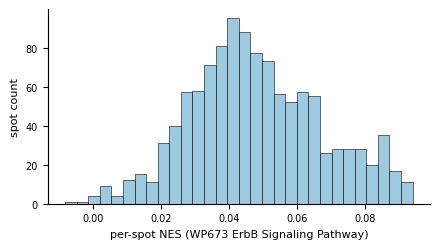

In [5]:
# Pivot to wide: rows=spots, cols=pathways, values=NES
nes_wide = nes_long.pivot_table(index="spot_id", columns="pathway", values="NES")
print(f"wide NES table: {nes_wide.shape}")

fig, ax = plt.subplots(figsize=(4.5, 2.6))
ax.hist(nes_wide['ErbB Signaling Pathway WP673'].dropna(), bins=30, color='#9ecae1', edgecolor='black', linewidth=0.4)
ax.set_xlabel("per-spot NES (WP673 ErbB Signaling Pathway)", fontsize=8)
ax.set_ylabel("spot count", fontsize=8); ax.tick_params(labelsize=7)
sns.despine(); fig.tight_layout(); plt.show()

## 4. Join GSEA + deconvolution, cancer-normalize

Each spot's GSEA NES is divided by its cancer-cell (Epithelial) fraction,
restricting the pathway signal to the cancer compartment of the tissue.
Spots are then rasterized onto a grid (tile size 320 px, the Visium
centre-to-centre spacing) for Moran's I.

In [6]:
# spot_id format is 'slide_pixel_x_pixel_y' — extract integer pixel coords
ids = nes_wide.index.to_series().str.split('_', expand=True)
nes_wide["px"] = ids.iloc[:, -2].astype(int)
nes_wide["py"] = ids.iloc[:, -1].astype(int)

# Build per-spot grid coords (tile_size = 320 px = Visium spot spacing)
TILE = 320
grid = pd.DataFrame({
    "x":  ((exp["x"] - exp["x"].min()) / TILE).round().astype(int).values,
    "y":  ((exp["y"] - exp["y"].min()) / TILE).round().astype(int).values,
    "px": exp["x"].astype(int).values,
    "py": exp["y"].astype(int).values,
}, index=exp.index)
# Merge NES onto grid by pixel coords
merged = grid.merge(
    nes_wide.reset_index(), on=["px", "py"], how="inner").set_index(grid.index.intersection(grid.index))
merged["Epithelial"] = ensemble["Epithelial"].loc[merged.index].values

PATHWAY = "ErbB Signaling Pathway WP673"
merged["signal"] = merged[PATHWAY] / merged["Epithelial"]
print(f"merged spots with NES + ensemble fraction: {len(merged)}")
print("cancer-normalized signal (NES / Epithelial) summary:")
print(merged['signal'].describe().round(3))

merged spots with NES + ensemble fraction: 1141
cancer-normalized signal (NES / Epithelial) summary:
count    1141.000
mean        0.182
std         0.159
min        -0.077
25%         0.124
50%         0.158
75%         0.198
max         3.409
Name: signal, dtype: float64


## 5. Compute SPAND on the cancer-restricted pathway signal

`spand_for_slide` rasterizes the signal onto the spot grid, computes Global
Moran's I against the grid adjacency, and divides by the signal mean. The
paper convention negates the result (so positive values mean more spatially
heterogeneous), which we apply here for consistency with the bundled
per-patient PBCP scores.

In [7]:
xy = merged[["x", "y"]]
raw_spand = spand_for_slide(merged["signal"], xy)
her2_spand = -1.0 * raw_spand

print(f"Moran's I / mean         = {raw_spand:+.4f}")
print(f"HER2-SPAND (paper sign)  = {her2_spand:+.4f}   (negated by convention)")

# Sanity-check: compare to the precomputed per-patient HER2-SPAND in the bundled table.
ref = pd.read_parquet("../data/pbcp_her2_scores.parquet").set_index("slide_name")
slide_id = "732799"
if slide_id in ref.index:
    ref_val = ref.loc[slide_id, "her2_spand"]
    print(f"\nbundled reference HER2-SPAND for {slide_id}: {ref_val:+.4f}")
    print(f"absolute difference:                 {abs(her2_spand - ref_val):.4f}")

Moran's I / mean         = +3.5623
HER2-SPAND (paper sign)  = -3.5623   (negated by convention)

bundled reference HER2-SPAND for 732799: -3.5777
absolute difference:                 0.0154


## 6. The pieces of SPAND, separately

For pedagogy, show each contributing factor on the same slide:

1. SPAND on raw ERBB2 (single-gene, no cancer restriction, no pathway).
2. SPAND on the raw WP673 NES (no cancer restriction).
3. SPAND on the cancer-restricted WP673 signal (the paper score).

In [8]:
# Reload exp with grid coords for ERBB2
exp_grid = exp.copy()
exp_grid["x"] = ((exp["x"] - exp["x"].min()) / TILE).round().astype(int)
exp_grid["y"] = ((exp["y"] - exp["y"].min()) / TILE).round().astype(int)

rows = [
    ("raw ERBB2 (single gene)",            spand_for_slide(exp_grid["ERBB2"], exp_grid[["x","y"]])),
    ("raw WP673 pathway NES",              spand_for_slide(merged[PATHWAY],   xy)),
    ("cancer-restricted WP673 (paper)",    spand_for_slide(merged["signal"],  xy)),
]
print(f"{'signal':<38s}{'Morans I / mean':>18s}")
for label, v in rows:
    print(f"{label:<38s}{v:>18.4f}")

signal                                   Morans I / mean
raw ERBB2 (single gene)                           3.3304
raw WP673 pathway NES                            18.4540
cancer-restricted WP673 (paper)                   3.5623


## Takeaway

The end-to-end pipeline runs in seconds on one slide. The cancer-restricted
WP673 SPAND is the value the downstream HER2-low / -high analysis
(notebook 02) compares to clinical response across the PBCP cohort.
Computing those per-patient scores at scale across PBCP / IMPRESS / TransNEO
requires the full Path2Space prediction pipeline (in the companion repo) and
is not reproduced inline here; only the precomputed per-patient table is
bundled for notebook 02.